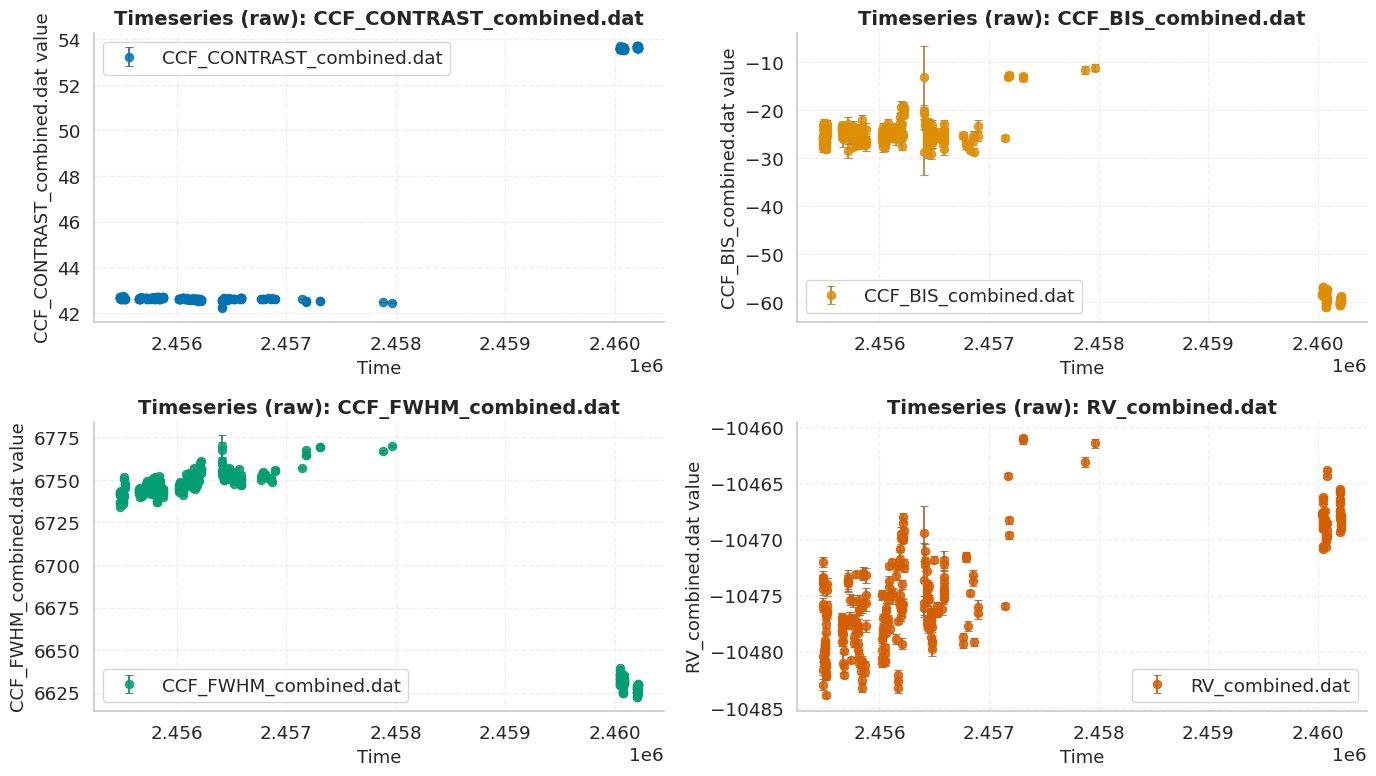

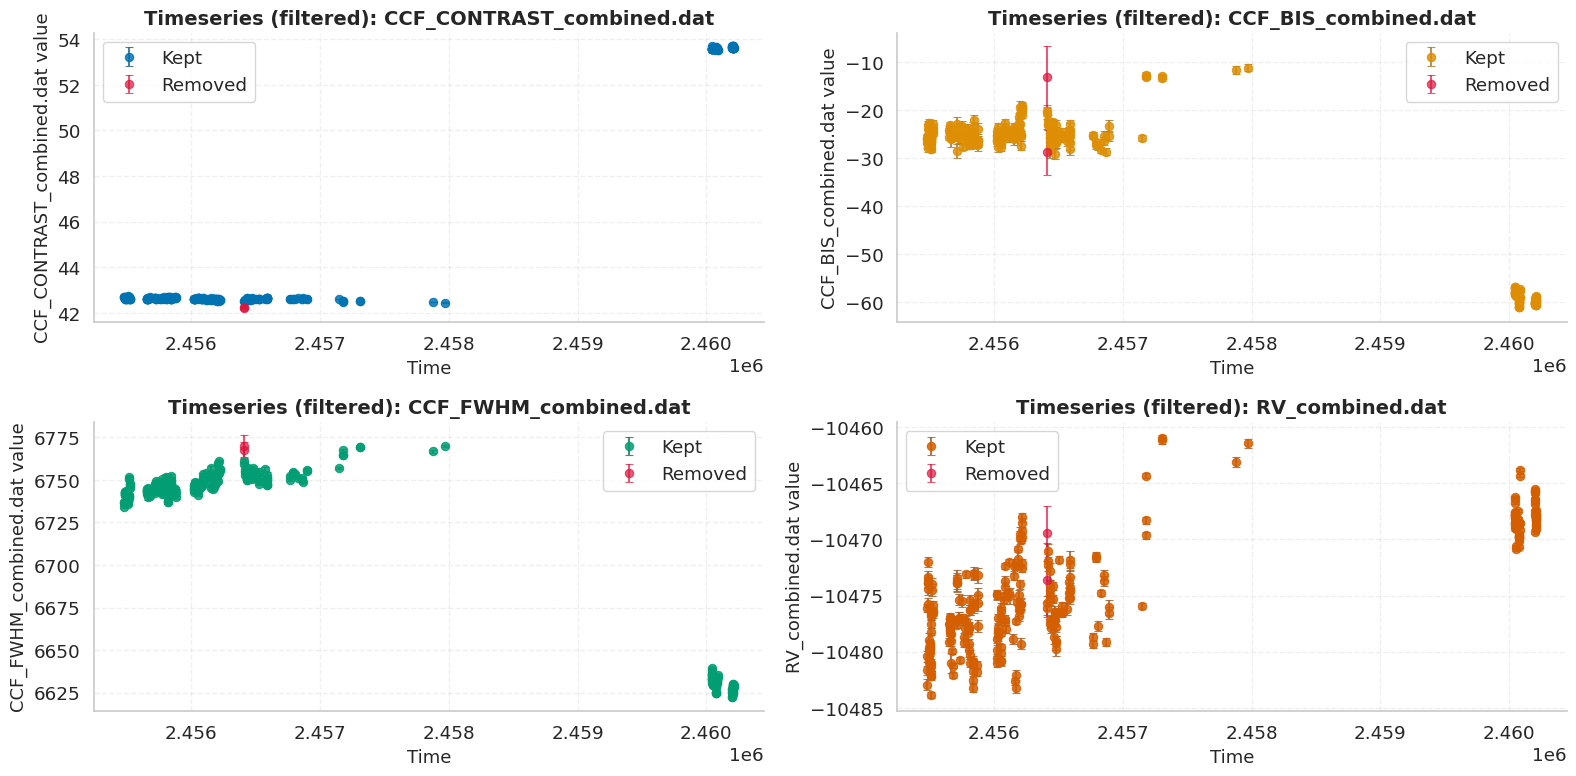

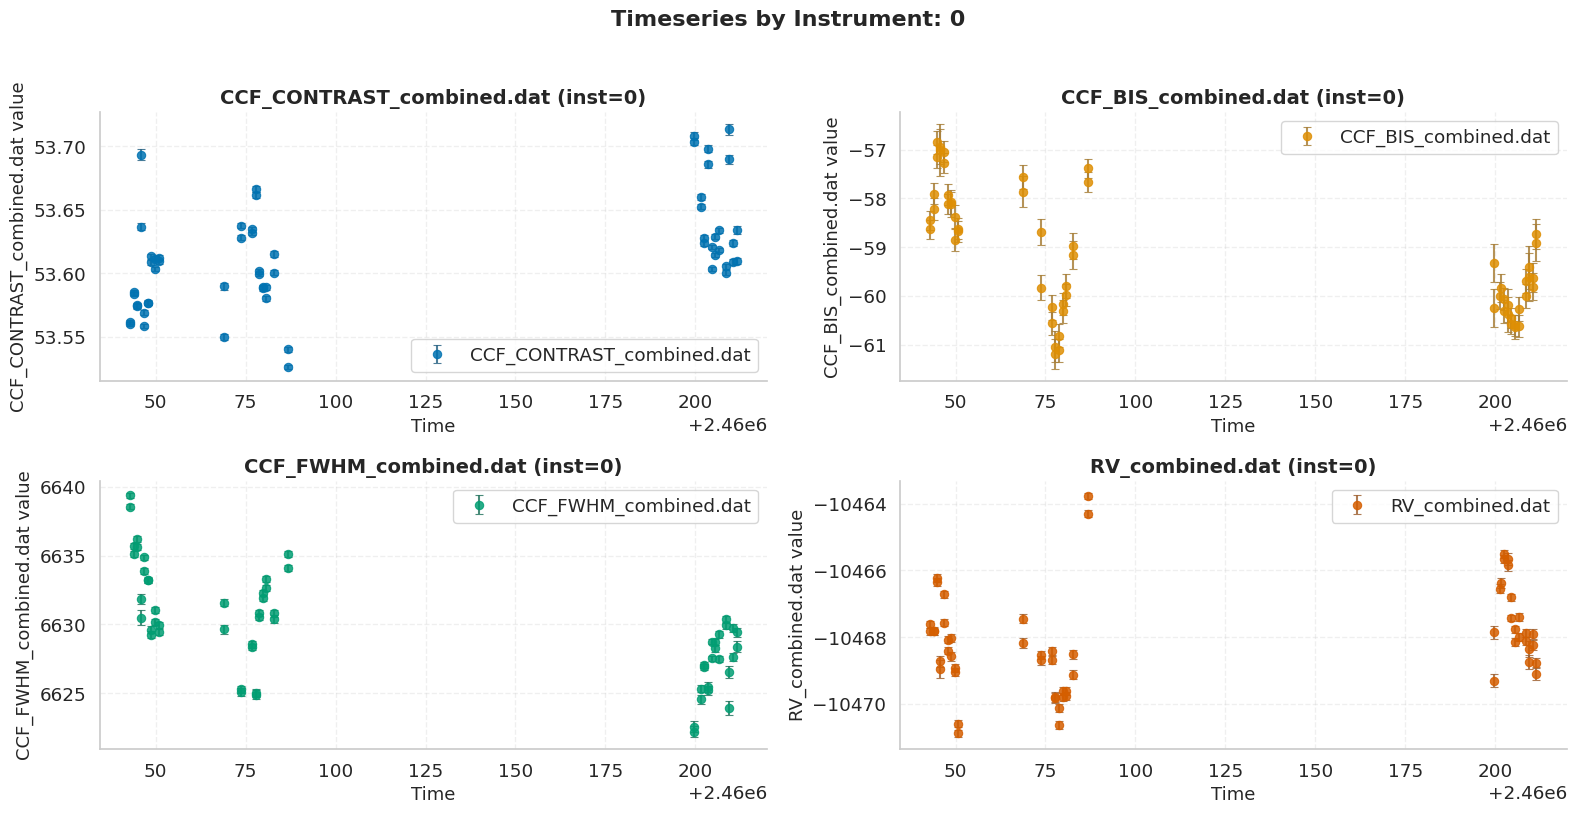

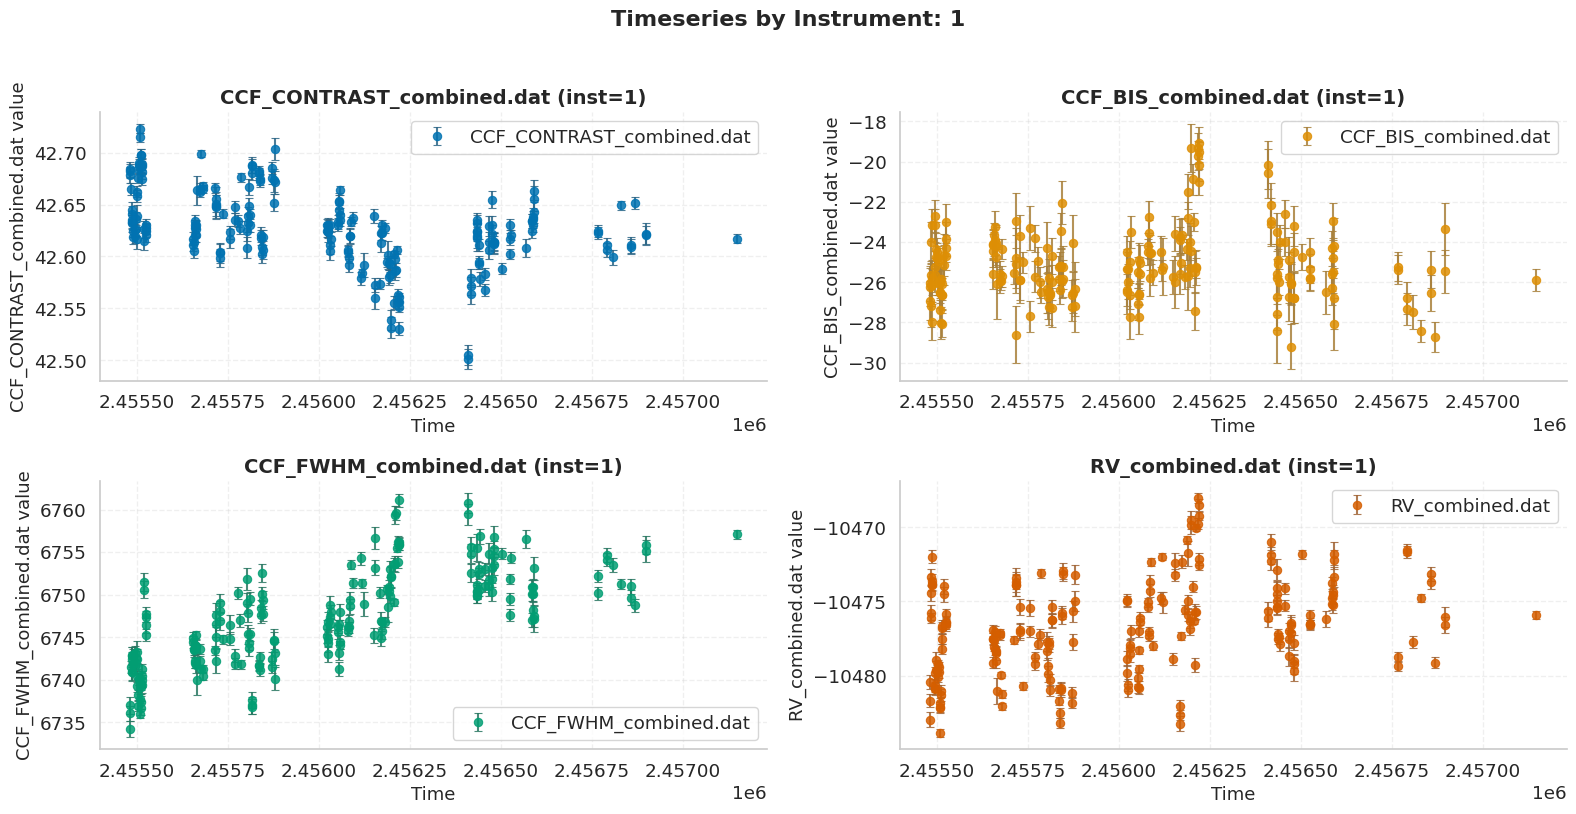

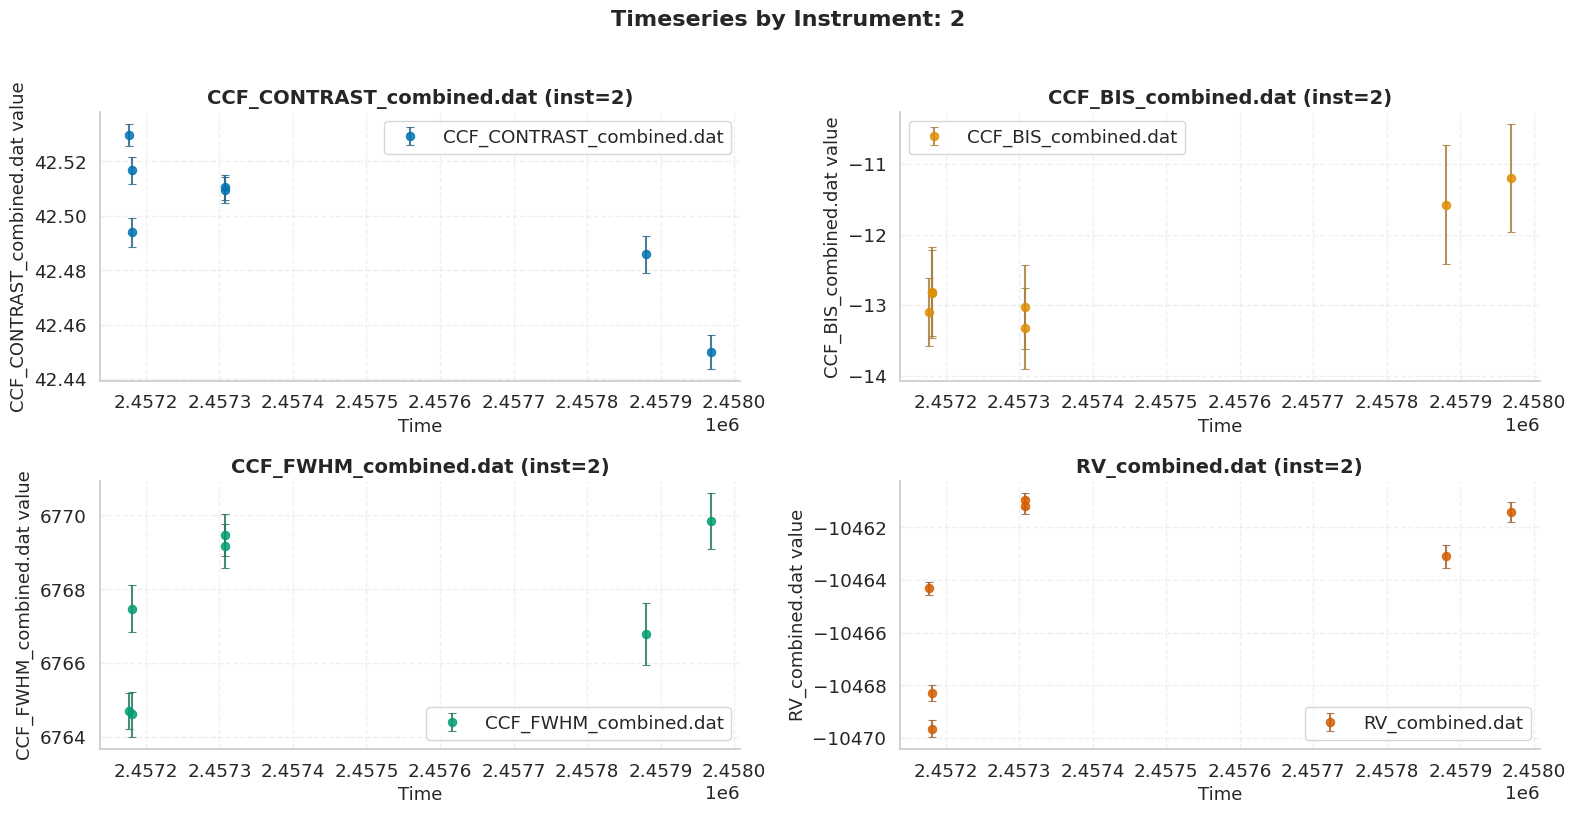

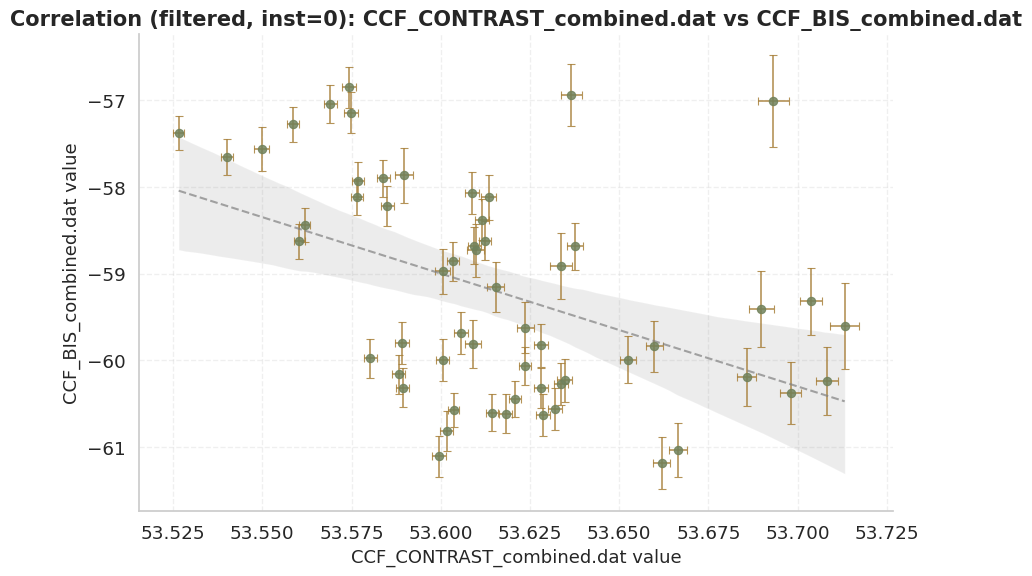

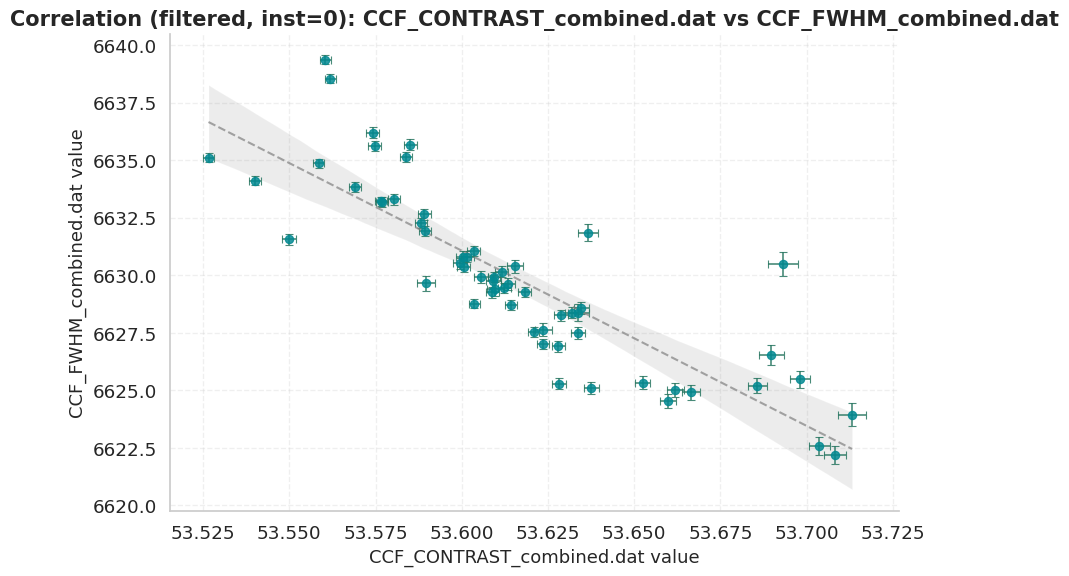

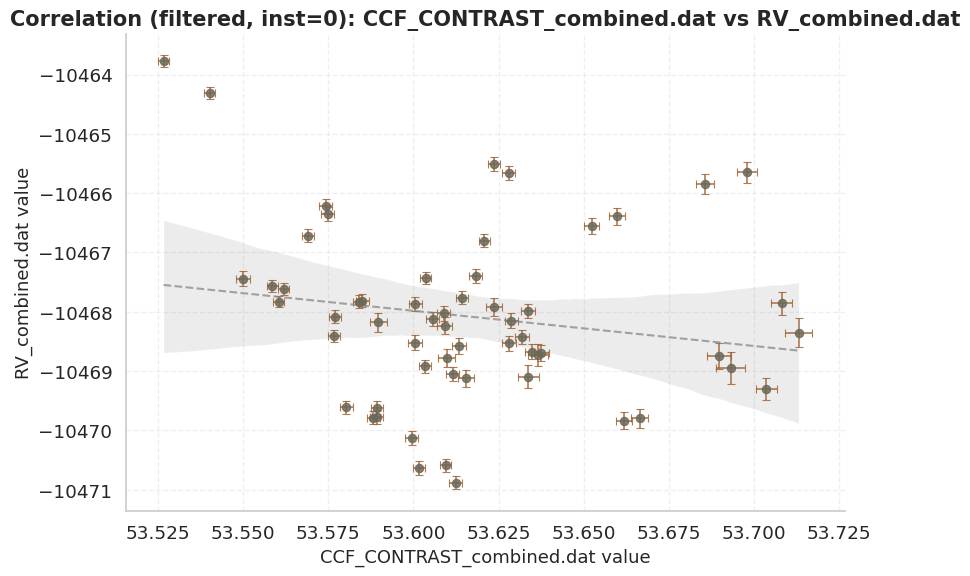

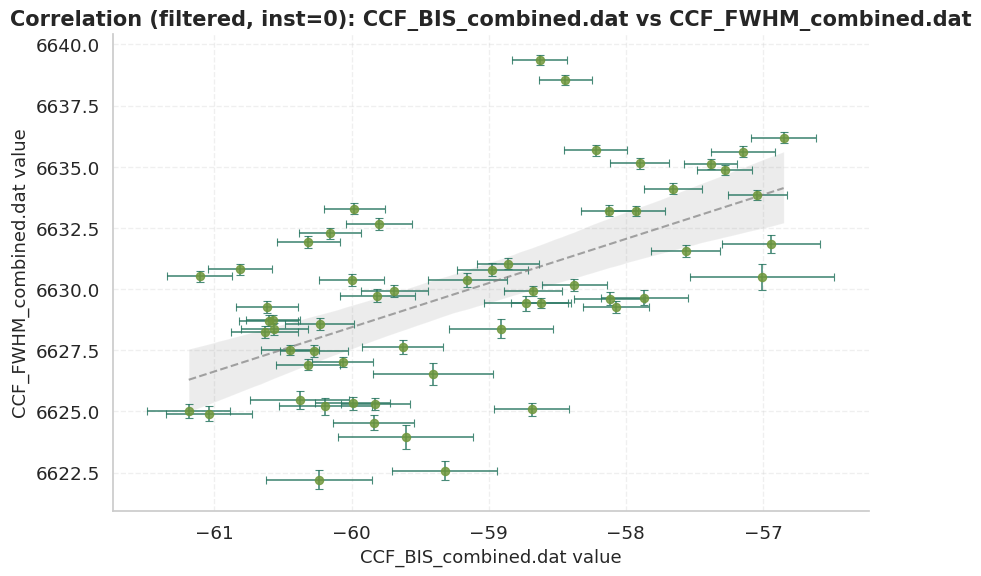

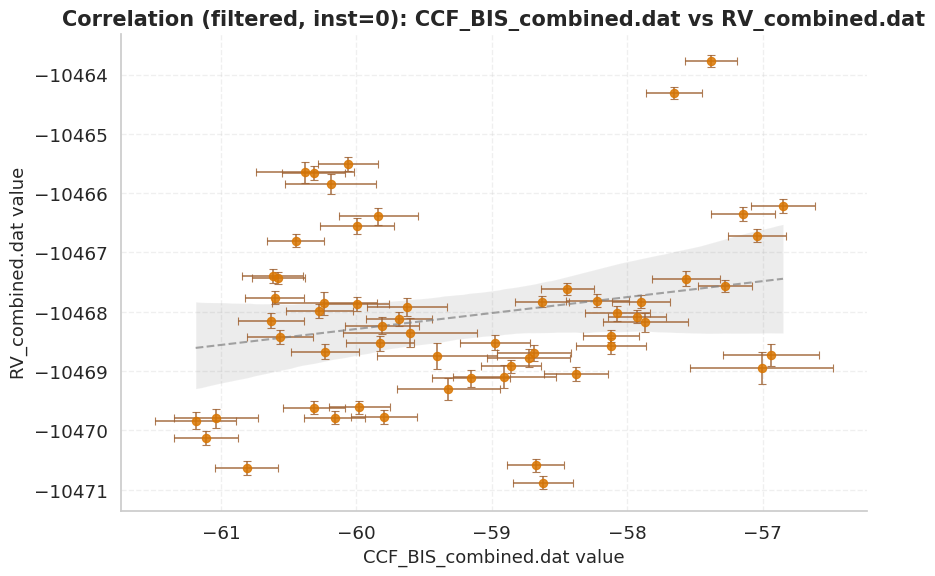

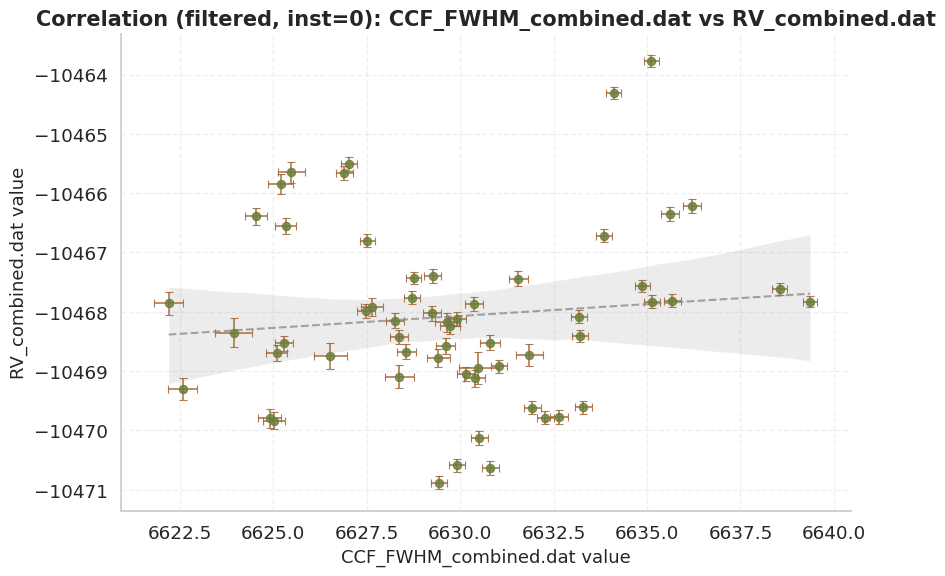

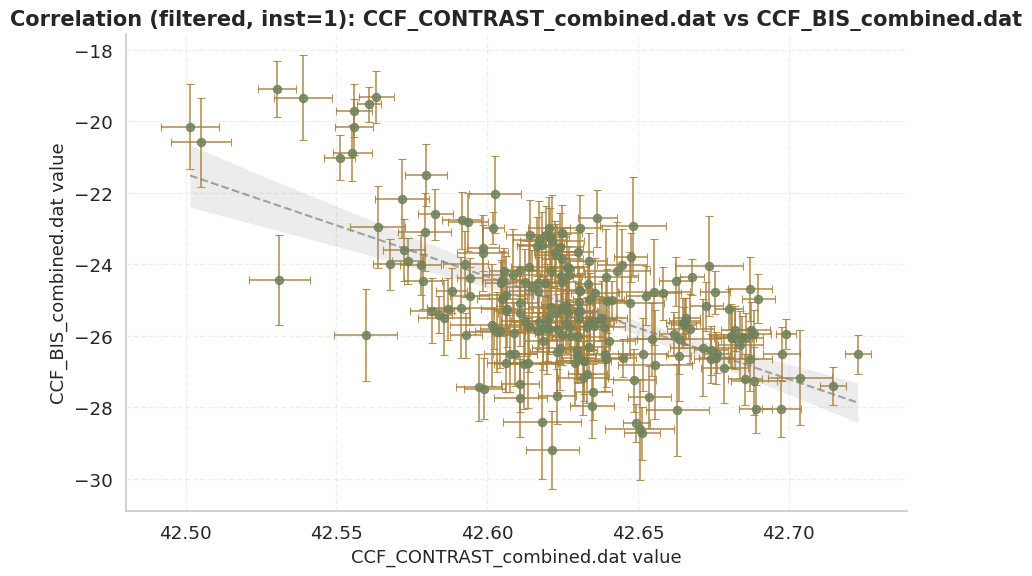

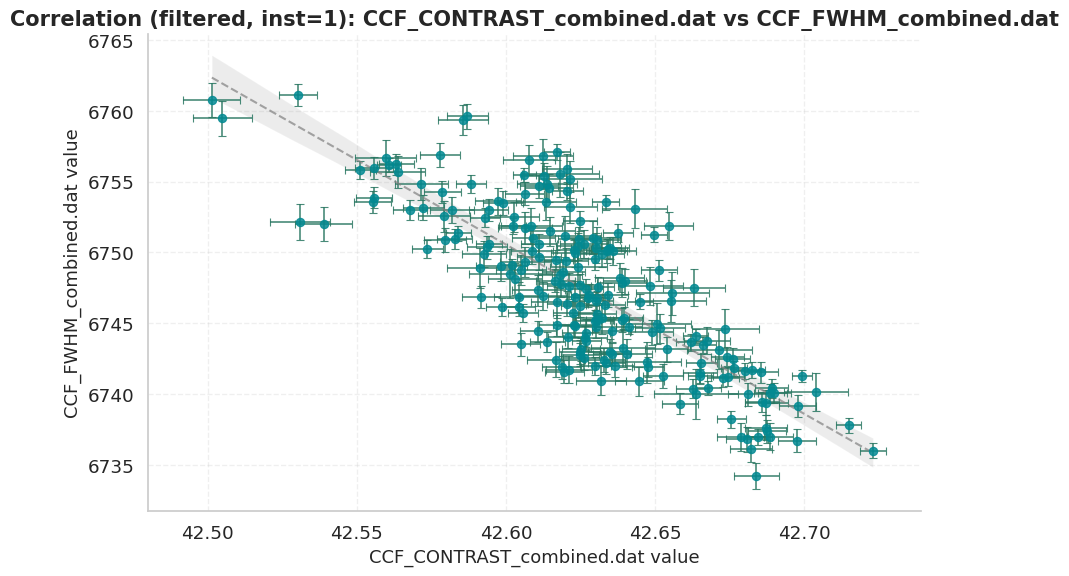

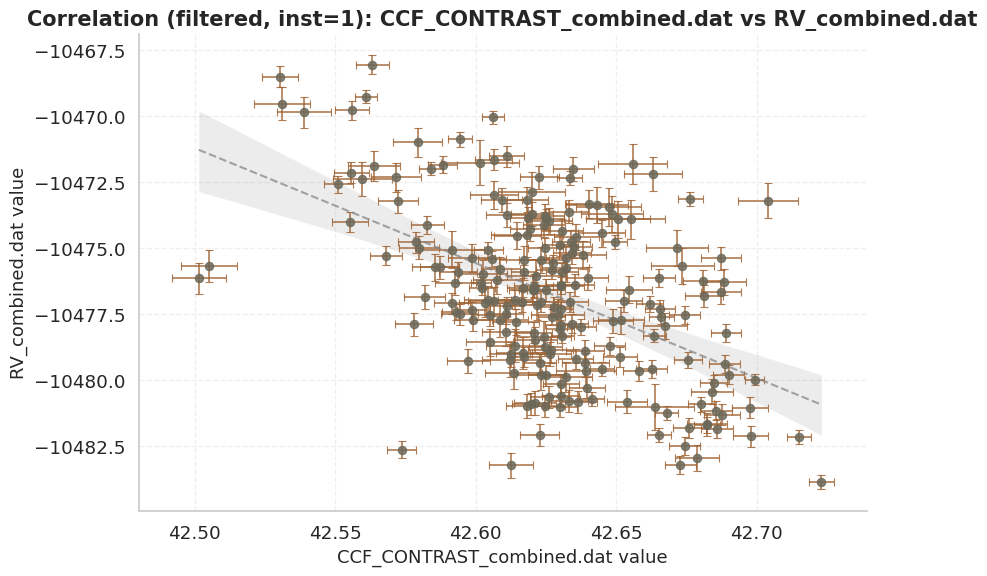

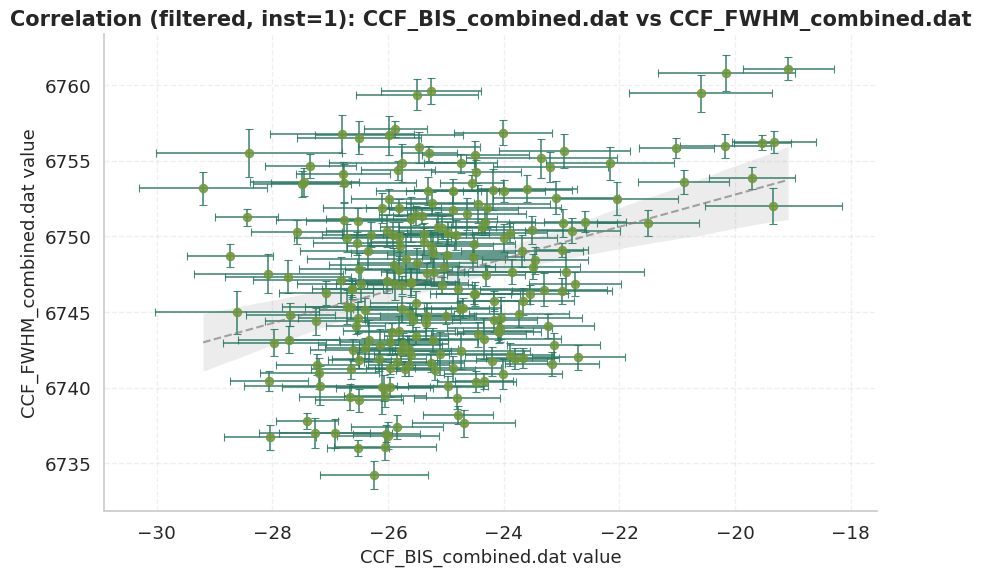

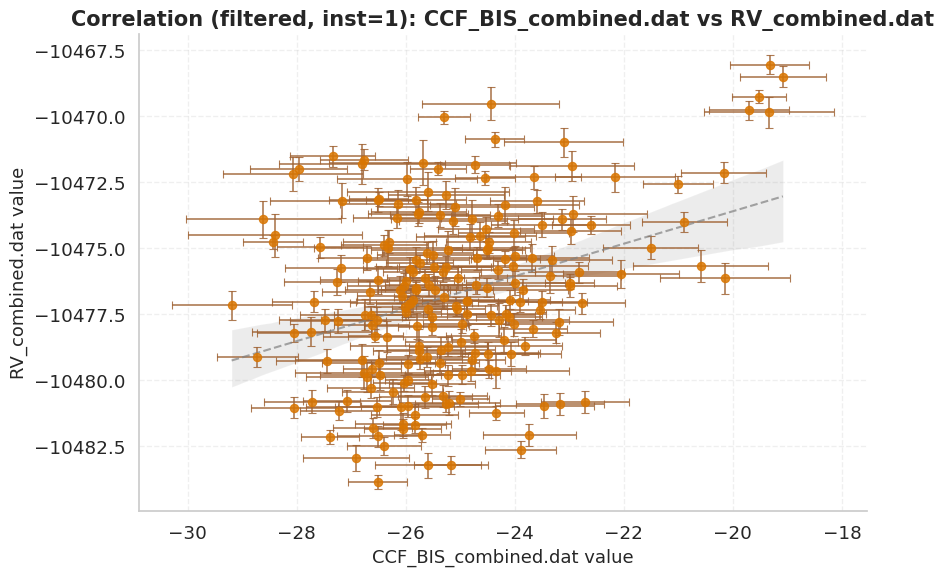

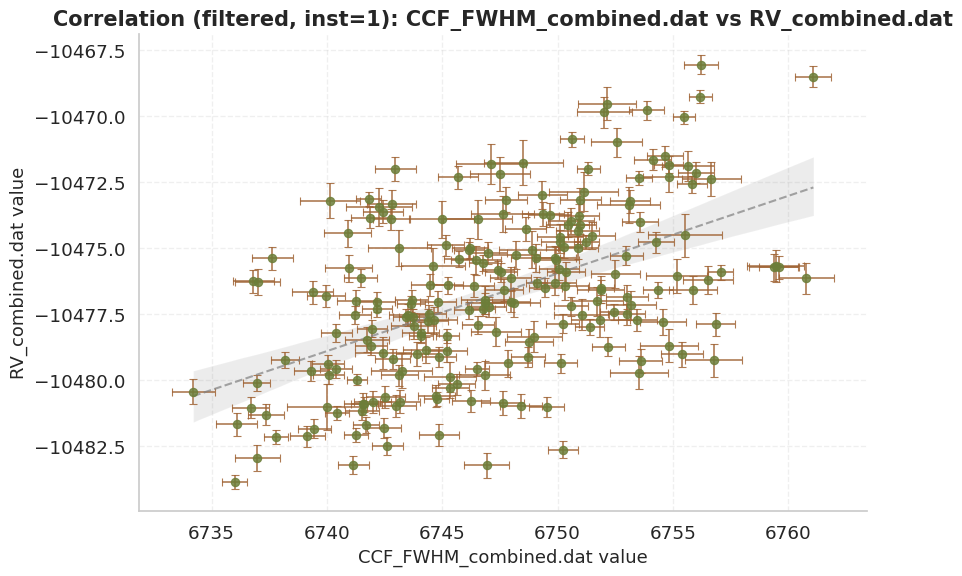

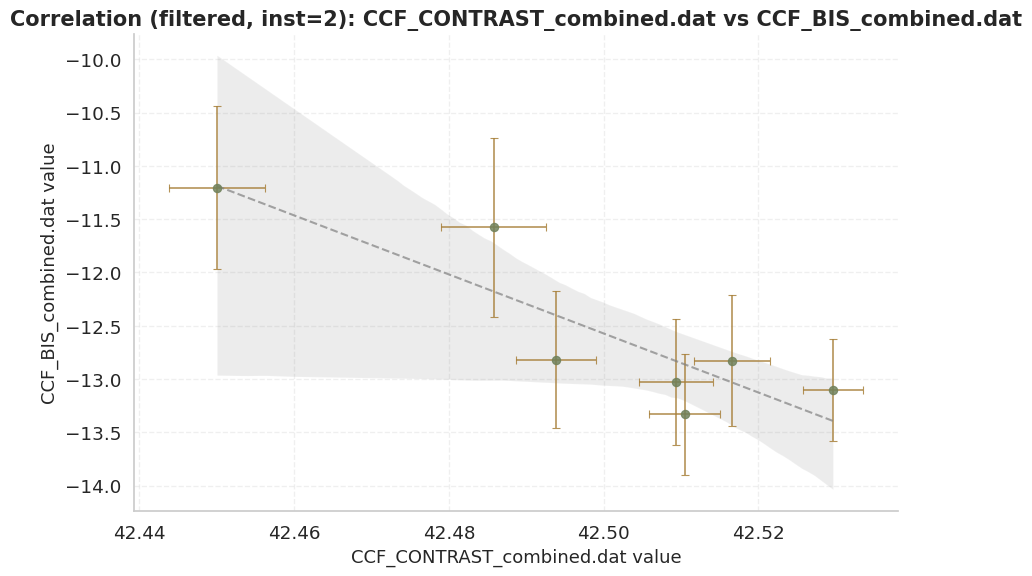

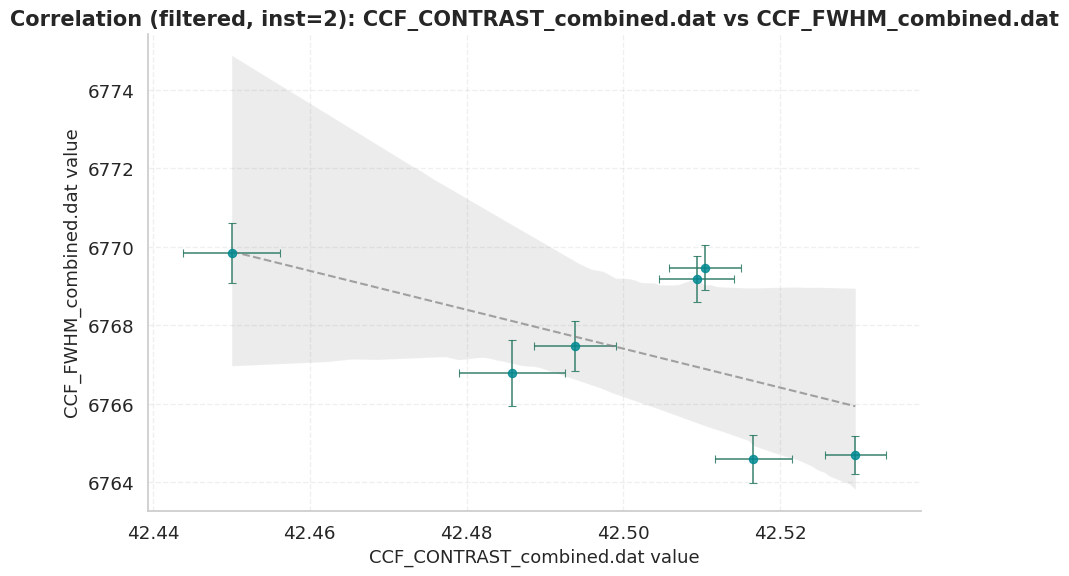

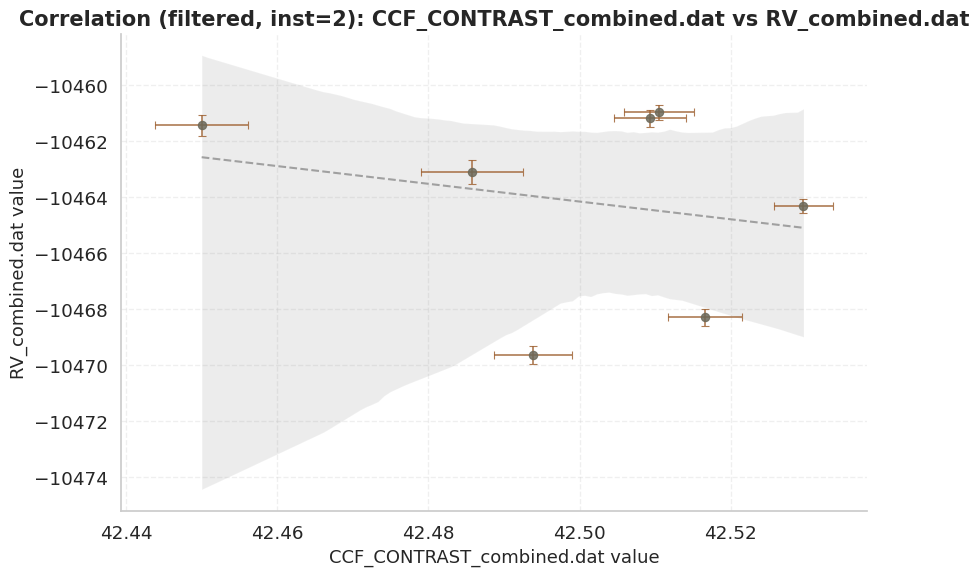

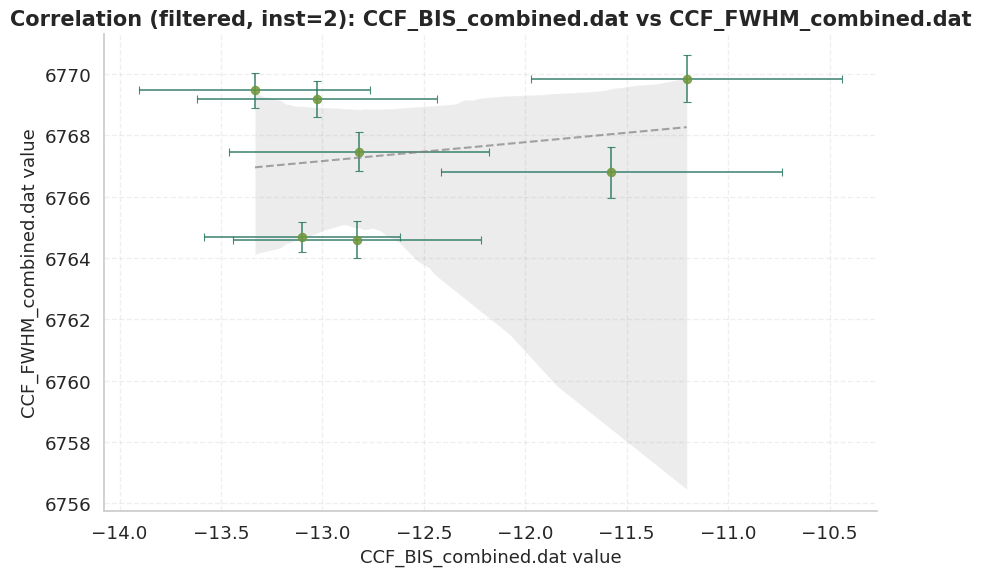

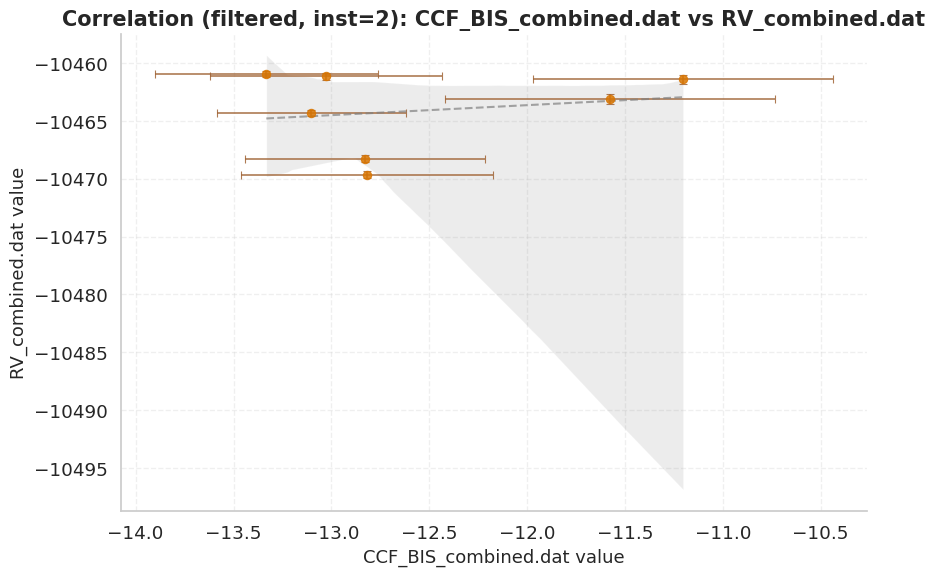

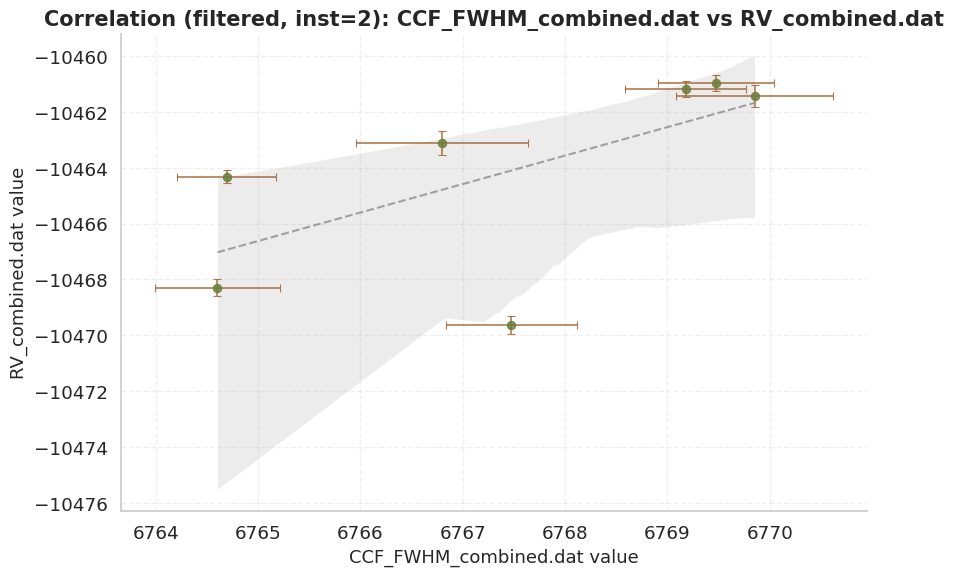

In [13]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set seaborn style for beautiful plots
sns.set(style="whitegrid", context="notebook", font_scale=1.2, palette="deep")

# Path to the data directory
dir = 'Combined/with_large_errorbar'

# Get all files in the directory, but skip subdirectories (e.g., 'filtered')
data_files = [
    f for f in glob.glob(os.path.join(dir, '*'))
    if os.path.isfile(f)
]

# Dictionary to store data for each file
data_dict = {}

# Helper: get format string for a file by reading its first non-comment, non-empty line
def infer_format_string(file_path):
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip() and not line.strip().startswith('#'):
                fields = line.rstrip('\n').split()
                fmt = []
                for val in fields:
                    # Try to infer int vs float
                    try:
                        if '.' in val or 'e' in val.lower():
                            float(val)
                            # preserve decimal places
                            if '.' in val:
                                decimals = len(val.split('.')[-1].rstrip('0')) if '.' in val else 0
                                if decimals == 0:
                                    decimals = 8  # fallback
                                fmt.append(f'%0.{decimals}f')
                            else:
                                fmt.append('%.8f')
                        else:
                            int(val)
                            fmt.append('%d')
                    except Exception:
                        fmt.append('%s')
                # Join with a single space, as in the original file
                return ' '.join(fmt)
    # fallback
    return None

# Read and store data for each file
format_dict = {}  # key: filename, value: format string
for file_path in data_files:
    try:
        # Try to read the file as whitespace-delimited, skip empty/comment lines
        data = []
        with open(file_path, 'r') as f:
            for line in f:
                if line.strip() and not line.strip().startswith('#'):
                    data.append([float(x) for x in line.strip().split()])
        if len(data) == 0:
            continue
        data = np.array(data)
        # Store as dict: key = filename, value = dict with time, value, yerr, and all columns
        file_key = os.path.basename(file_path)
        entry = {
            'time': data[:, 0],
            'value': data[:, 1],
            'all': data
        }
        if data.shape[1] > 2:
            entry['yerr'] = data[:, 2]
        else:
            entry['yerr'] = None
        # Try to infer instrument from last column if present
        if data.shape[1] > 4:
            entry['instrument'] = data[:, 4].astype(int)
        elif data.shape[1] > 3:
            entry['instrument'] = data[:, 3].astype(int)
        else:
            entry['instrument'] = np.full(data.shape[0], -1)
        data_dict[file_key] = entry
        # Infer format string for this file
        fmt = infer_format_string(file_path)
        format_dict[file_key] = fmt
    except Exception as e:
        print(f"Could not process {file_path}: {e}")

# Define a color palette for consistency
palette = sns.color_palette("colorblind", n_colors=len(data_dict))
color_map = {k: palette[i] for i, k in enumerate(data_dict.keys())}

# --- Plot timeseries for each variable (before outlier removal) ---
# Group all time series into a single figure with subplots
n_files = len(data_dict)
ncols = 2
nrows = int(np.ceil(n_files / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*7, nrows*4), squeeze=False)
for idx, (key, d) in enumerate(data_dict.items()):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]
    color = color_map[key]
    if d['yerr'] is not None:
        ax.errorbar(
            d['time'], d['value'], yerr=d['yerr'],
            fmt='o', alpha=0.85, color=color, ecolor=sns.desaturate(color, 0.5),
            elinewidth=1.5, capsize=3, markeredgewidth=0.8, markersize=6, label=key
        )
    else:
        ax.plot(d['time'], d['value'], 'o', alpha=0.85, color=color, markersize=6, label=key)
    ax.set_xlabel("Time", fontsize=13)
    ax.set_ylabel(f"{key} value", fontsize=13)
    ax.set_title(f"Timeseries (raw): {key}", fontsize=14, weight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='best', frameon=True)
# Hide unused subplots
for idx in range(n_files, nrows*ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].axis('off')
plt.tight_layout()
plt.show()

# Remove data points with extra large error bars and save them
removed_points = {}  # key: filename, value: dict of removed points

# Also, save filtered data to new files
filtered_dir = os.path.join(dir, "filtered")
os.makedirs(filtered_dir, exist_ok=True)

for key, d in data_dict.items():
    fmt = format_dict.get(key, None)
    if d['yerr'] is not None:
        yerr = d['yerr']
        # Define "extra large" as > 3x median error
        threshold = 3 * np.median(yerr)
        mask_good = yerr <= threshold
        mask_bad = ~mask_good
        # Save removed points
        removed_points[key] = {
            'time': d['time'][mask_bad],
            'value': d['value'][mask_bad],
            'yerr': d['yerr'][mask_bad]
        }
        # Keep only good points
        data_dict[key]['time'] = d['time'][mask_good]
        data_dict[key]['value'] = d['value'][mask_good]
        data_dict[key]['yerr'] = d['yerr'][mask_good]
        data_dict[key]['all'] = d['all'][mask_good]
        data_dict[key]['instrument'] = d['instrument'][mask_good]
        # Save filtered data to new file
        filtered_path = os.path.join(filtered_dir, key.replace('.dat', '_filtered.dat'))
        # Write using the same format as the original file, but with tab as separator
        if fmt is not None:
            fmt_tab = fmt.replace(' ', '\t')
            with open(filtered_path, 'w') as f:
                for row in data_dict[key]['all']:
                    f.write((fmt_tab % tuple(row)) + '\n')
        else:
            np.savetxt(filtered_path, data_dict[key]['all'], fmt='%.8f', delimiter='\t')
    else:
        removed_points[key] = {
            'time': np.array([]),
            'value': np.array([]),
            'yerr': np.array([])
        }
        # Save filtered data to new file (all points kept)
        filtered_path = 'Combined'
        if fmt is not None:
            fmt_tab = fmt.replace(' ', '\t')
            with open(filtered_path, 'w') as f:
                for row in d['all']:
                    f.write((fmt_tab % tuple(row)) + '\n')
        else:
            np.savetxt(filtered_path, d['all'], fmt='%.8f', delimiter='\t')

# --- Plot timeseries for each variable (after outlier removal) ---
# Group all time series into a single figure with subplots
n_files = len(data_dict)
ncols = 2
nrows = int(np.ceil(n_files / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*8, nrows*4), squeeze=False)
for idx, (key, d) in enumerate(data_dict.items()):
    row, col = divmod(idx, ncols)
    ax = axes[row][col]
    color = color_map[key]
    if d['yerr'] is not None:
        ax.errorbar(
            d['time'], d['value'], yerr=d['yerr'],
            fmt='o', alpha=0.85, color=color, ecolor=sns.desaturate(color, 0.5),
            elinewidth=1.5, capsize=3, markeredgewidth=0.8, markersize=6, label='Kept'
        )
        # Optionally, plot removed points in red
        if len(removed_points[key]['time']) > 0:
            ax.errorbar(
                removed_points[key]['time'], removed_points[key]['value'],
                yerr=removed_points[key]['yerr'], fmt='o', color='crimson', ecolor='crimson',
                alpha=0.7, elinewidth=1.5, capsize=3, markeredgewidth=0.8, markersize=6, label='Removed'
            )
        ax.legend(loc='best', frameon=True)
    else:
        ax.plot(d['time'], d['value'], 'o', alpha=0.85, color=color, markersize=6, label='Kept')
    ax.set_xlabel("Time", fontsize=13)
    ax.set_ylabel(f"{key} value", fontsize=13)
    ax.set_title(f"Timeseries (filtered): {key}", fontsize=14, weight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)
# Hide unused subplots
for idx in range(n_files, nrows*ncols):
    row, col = divmod(idx, ncols)
    axes[row][col].axis('off')
plt.tight_layout()
plt.show()

# --- Plot timeseries by instrument (after outlier removal) ---
# First, collect all unique instrument codes
all_instruments = set()
for d in data_dict.values():
    if 'instrument' in d:
        all_instruments.update(np.unique(d['instrument']))
# Remove -1 (unknown) if present
all_instruments = sorted([i for i in all_instruments if i != -1])

file_keys = list(data_dict.keys())
n_files = len(file_keys)

for inst in all_instruments:
    # For each instrument, plot all variables in a single figure with subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*8, nrows*4), squeeze=False)
    for idx, key in enumerate(file_keys):
        d = data_dict[key]
        row, col = divmod(idx, ncols)
        ax = axes[row][col]
        color = color_map[key]
        mask = (d['instrument'] == inst)
        if np.sum(mask) == 0:
            ax.set_visible(False)
            continue
        if d['yerr'] is not None:
            ax.errorbar(
                d['time'][mask], d['value'][mask], yerr=d['yerr'][mask],
                fmt='o', alpha=0.85, color=color, ecolor=sns.desaturate(color, 0.5),
                elinewidth=1.5, capsize=3, markeredgewidth=0.8, markersize=6, label=f'{key}'
            )
        else:
            ax.plot(d['time'][mask], d['value'][mask], 'o', alpha=0.85, color=color, markersize=6, label=f'{key}')
        ax.set_xlabel("Time", fontsize=13)
        ax.set_ylabel(f"{key} value", fontsize=13)
        ax.set_title(f"{key} (inst={inst})", fontsize=14, weight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(loc='best', frameon=True)
    # Hide unused subplots
    for idx in range(n_files, nrows*ncols):
        row, col = divmod(idx, ncols)
        axes[row][col].axis('off')
    plt.suptitle(f"Timeseries by Instrument: {inst}", fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# --- Plot correlations by instrument ---

for inst in all_instruments:
    # For each instrument, plot all pairs
    for i in range(n_files):
        for j in range(i+1, n_files):
            key1 = file_keys[i]
            key2 = file_keys[j]
            d1 = data_dict[key1]
            d2 = data_dict[key2]
            # Find times for this instrument in both datasets
            mask1 = (d1['instrument'] == inst)
            mask2 = (d2['instrument'] == inst)
            t1 = d1['time'][mask1]
            t2 = d2['time'][mask2]
            # Use intersection of times
            common_times = np.intersect1d(t1, t2)
            if len(common_times) == 0:
                continue
            idx1 = np.isin(t1, common_times)
            idx2 = np.isin(t2, common_times)
            v1 = d1['value'][mask1][idx1]
            v2 = d2['value'][mask2][idx2]
            yerr1 = d1['yerr'][mask1][idx1] if d1['yerr'] is not None else None
            yerr2 = d2['yerr'][mask2][idx2] if d2['yerr'] is not None else None

            fig, ax = plt.subplots(figsize=(9, 6))
            color1 = color_map[key1]
            color2 = color_map[key2]
            if yerr1 is not None and yerr2 is not None:
                ax.errorbar(
                    v1, v2, xerr=yerr1, yerr=yerr2, fmt='o',
                    alpha=0.85, color=sns.blend_palette([color1, color2], n_colors=3)[1],
                    ecolor=sns.desaturate(color2, 0.5), elinewidth=1.2, capsize=3, markeredgewidth=0.8, markersize=6
                )
            else:
                ax.scatter(
                    v1, v2, alpha=0.85, color=sns.blend_palette([color1, color2], n_colors=3)[1],
                    edgecolor='k', s=60
                )
            # Add a regression line if enough points
            if len(v1) > 2:
                sns.regplot(x=v1, y=v2, scatter=False, ax=ax, color='gray', line_kws={'lw':1.5, 'ls':'--', 'alpha':0.7})
            ax.set_xlabel(f"{key1} value", fontsize=13)
            ax.set_ylabel(f"{key2} value", fontsize=13)
            ax.set_title(f"Correlation (filtered, inst={inst}): {key1} vs {key2}", fontsize=15, weight='bold')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, linestyle='--', alpha=0.3)
            plt.tight_layout()
            plt.show()
